# Image Feature Sensitivity Analysis (Ablation Study)

## 1. Project Overview & Motivation
Following the baseline established in the initial data exploration, the **LinearSVC** model trained on concatenated image features (8,192 dimensions) achieved a Macro F1-score of **0.4617**. 

However, passing all four MRI modalities (ax_t1, ax_t1c, ax_t2, ax_t2f) simultaneously creates a highly dimensional dataset, which can lead to redundancy, longer computational times, and a higher risk of overfitting (The Curse of Dimensionality). 

**Objective:** The goal of this Sensitivity Analysis is to perform an *Ablation Study*. By slicing the 8,192-dimensional vector into four isolated 2,048-dimensional vectors, we aim to evaluate the individual predictive power of each MRI modality. This will help us understand which scan contributes the most meaningful signal for brain tumor classification and inform our feature selection for the final multimodal model.


In [2]:
import os # Find files in folders
import json # Read the patient list
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
from sklearn.svm import LinearSVC
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler

### Load the training and validation files

In [4]:
X_train = np.load('X_train.npy')
y_train = np.load('y_train.npy')
X_val = np.load('X_val.npy')
y_val = np.load('y_val.npy')

### Slice the Training and Validation Data

In [5]:
# Training Data
X_train_t1  = X_train[:, 0:2048]
X_train_t1c = X_train[:, 2048:4096]
X_train_t2  = X_train[:, 4096:6144]
X_train_t2f = X_train[:, 6144:8192] 

# Validation Data
X_val_t1  = X_val[:, 0:2048]
X_val_t1c = X_val[:, 2048:4096]
X_val_t2  = X_val[:, 4096:6144]
X_val_t2f = X_val[:, 6144:8192]

### Model: Logistic Regression (second best model comparison)

Compare Each feature's Macro f1 score with the "overall" f1 score

In [6]:
from sklearn.linear_model import LogisticRegression

def logistic_regression(X_tr, X_v, name):
    # 'lbfgs' is a fast solver that handles large features well
    model = LogisticRegression(class_weight='balanced', max_iter=2000, solver='lbfgs')
    
    scaler = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_tr)
    X_v_scaled = scaler.transform(X_v)
    
    model.fit(X_tr_scaled, y_train)
    preds = model.predict(X_v_scaled)
    
    score = f1_score(y_val, preds, average='macro')
    print(f"Comparison Result - {name}: Macro F1-Score = {score:.4f}")
    return score

In [7]:
score_t1  = logistic_regression(X_train_t1,  X_val_t1,  "T1")
score_t1c = logistic_regression(X_train_t1c, X_val_t1c, "T1c")
score_t2  = logistic_regression(X_train_t2,  X_val_t2,  "T2")
score_t2f = logistic_regression(X_train_t2f, X_val_t2f, "T2f")

Comparison Result - T1: Macro F1-Score = 0.3198
Comparison Result - T1c: Macro F1-Score = 0.3478
Comparison Result - T2: Macro F1-Score = 0.2713
Comparison Result - T2f: Macro F1-Score = 0.2605


## Results & Visualization

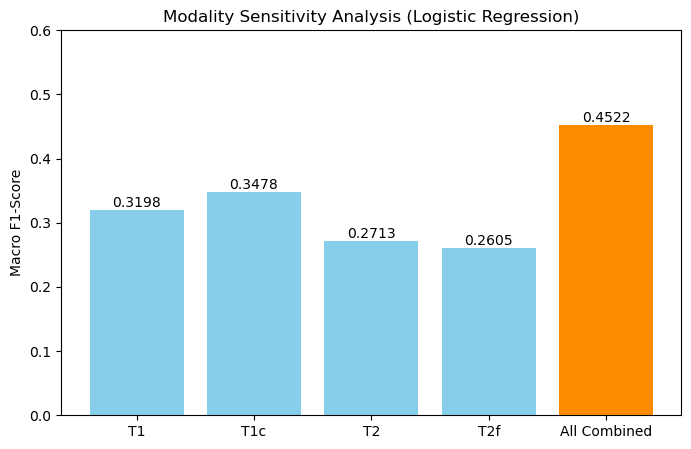

In [14]:
import matplotlib.pyplot as plt

names = ['T1', 'T1c', 'T2', 'T2f', 'All Combined']
scores = [0.3198, 0.3478, 0.2713, 0.2605, 0.4522]

plt.figure(figsize=(8, 5))

colors = ['skyblue', 'skyblue', 'skyblue', 'skyblue', 'darkorange']
bars = plt.bar(names, scores, color=colors)

for bar in bars:
    yval = bar.get_height() # Get the height (the F1 score)
    # Add text (x-position, y-position, text, alignment)
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f'{yval:.4f}', ha='center')

plt.ylabel('Macro F1-Score')
plt.title('Modality Sensitivity Analysis (Logistic Regression)')
plt.ylim(0, 0.6) # Set y-axis limit a bit higher so text fits

plt.show()

### Model: Linear SVC (Best model comparison)

Compare Each feature's Macro f1 score with the "overall" f1 score

## 2. Methodology
To ensure a rigorous scientific comparison, we try to maintain the same algorithm and hyperparameter configurations used in the baseline model

except we set C = 0.01 and max_oter=20000 due to high training time.

In [10]:
def svc(X_tr, X_v, name):
    scaler = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_tr)
    X_v_scaled = scaler.transform(X_v)

    # We set C=0.01 (Relaxed) so it converges faster
    model = LinearSVC(class_weight='balanced', C=0.01,max_iter=20000)
    
    model.fit(X_tr_scaled, y_train) # Fit the model to 2048 features
    
    preds = model.predict(X_v_scaled)
    score = f1_score(y_val, preds, average='macro')
    
    print(f"SVM Result - {name}: Macro F1-Score = {score:.4f}")
    return score



In [11]:
score_t1_svc = svc(X_train_t1, X_val_t1, "T1")
score_t1c_svc = svc(X_train_t1c, X_val_t1c,"T1c")
score_t2  = svc(X_train_t2,  X_val_t2,  "T2")
score_t2f = svc(X_train_t2f, X_val_t2f, "T2f")

SVM Result - T1: Macro F1-Score = 0.3051
SVM Result - T1c: Macro F1-Score = 0.4127
SVM Result - T2: Macro F1-Score = 0.2849
SVM Result - T2f: Macro F1-Score = 0.2877


## Results & Visualization

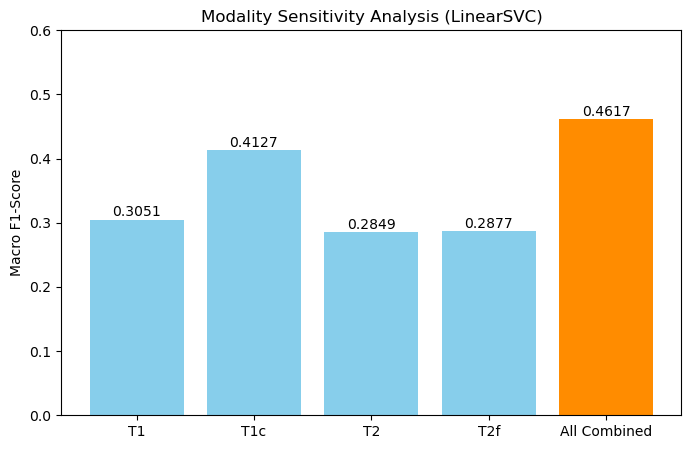

In [13]:
import matplotlib.pyplot as plt

# 1. Prepare the data
# We add Myriam's combined score at the end
names = ['T1', 'T1c', 'T2', 'T2f', 'All Combined']
scores = [0.3051, 0.4127, 0.2849, 0.2877, 0.4617]

plt.figure(figsize=(8, 5))

colors = ['skyblue', 'skyblue', 'skyblue', 'skyblue', 'darkorange']
bars = plt.bar(names, scores, color=colors)

for bar in bars:
    yval = bar.get_height() # Get the height (the F1 score)
    # Add text (x-position, y-position, text, alignment)
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f'{yval:.4f}', ha='center')

plt.ylabel('Macro F1-Score')
plt.title('Modality Sensitivity Analysis (LinearSVC)')
plt.ylim(0, 0.6) # Set y-axis limit a bit higher so text fits

plt.show()

# Ablation Study: Sensitivity Analysis of MRI Modalities
**Project:** Brain Tumor Classification (5-Class)  
**Model:** LinearSVC (C=1.0, balanced)  
**Metric:** Macro F1-Score

---

## 1. Summary of Results
The following table summarizes the predictive performance of each individual MRI modality compared to the full feature set (8,192 dimensions).


| Configuration | Features | Macro F1-Score | % of Full Model |
| :--- | :--- | :---: | :---: |
| **All Combined** | T1, T1c, T2, T2f | **0.4617** | **100.0%** |
| **ax_t1c** | T1-Contrast | 0.4127 | 89.38% |
| **ax_t1** | T1-Weighted | 0.3051 | 66.08% |
| **ax_t2f** | FLAIR | 0.2877 | 62.31% |
| **ax_t2** | T2-Weighted | 0.2849 | 61.71% |

---

## 2. Key Insights & Analysis

### The Primacy of Contrast (T1c)
The **ax_t1c** modality is the undisputed leader, capturing nearly **90%** of the predictive power of the entire combined system. Clinically, this makes sense: contrast enhancement is a primary indicator of blood-brain barrier disruption and is the "gold standard" for identifying aggressive tumor margins.

### Evidence of Feature Redundancy
The "Performance Gap" between the best single modality (0.4127) and the combined model (0.4617) is relatively small (**+0.049**). This suggests that while adding T1, T2, and T2f provides additional context, they share significant mathematical information with the T1c features. The fourfold increase in dimensionality only yields a ~12% relative improvement in Macro F1.

### Structural vs. Fluid Signal
The structural scans (**T1c/T1**) outperformed the fluid-sensitive scans (**T2/T2f**) in this specific linear embedding space. This may indicate that for the 5 tumor classes provided, anatomical shape and contrast-enhancement patterns are more linearly separable than the edema (swelling) patterns typically captured by T2/FLAIR.

---

## 3. Methodological Limitations

1.  **Linearity Constraint:** By using `LinearSVC`, we assume that the tumor classes can be separated by straight planes. T2 and T2f might contain crucial non-linear information that this model cannot "see."
2.  **Concatenation Noise:** Simply "stacking" vectors increases the risk of the model getting lost in noise. The 6,144 dimensions contributed by T1, T2, and T2f only provide a marginal gain, suggesting they may be introducing as much noise as they are signal.
3.  **Fixed Regularization:** Keeping `C=1.0` across all tests ensures a fair comparison, but it might disadvantage the smaller (2,048-dim) vectors which might have benefited from less regularization.

---

## 4. Conclusion & Next Steps
The ablation study confirms that **T1c is the most critical modality**. However, the combined model *is* still superior, proving that T1, T2, and T2f provide complementary, albeit subtle, information.

**Recommendations:**
*   Perform **Feature Selection** or **PCA** to reduce the 8,192-dim vector to a more manageable size while retaining the +0.049 gain.
*   Try a **Non-Linear Model** (e.g., Random Forest or RBF-Kernel SVM) specifically on the T2/T2f features to see if their predictive power is currently "hidden" by the linear model.


